In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [3]:
import yfinance as yf
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622
...,...,...,...,...,...
2023-12-22,1267.243042,1275.073539,1258.646635,1264.550536,16541784
2023-12-26,1273.665527,1280.532666,1266.081931,1268.700379,7465664


In [5]:
stk_data.columns=stk_data.columns.get_level_values(0)

In [6]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [7]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956671,680.008852,670.390532,672.216187
2020-01-02,673.284921,686.176208,673.284921,683.660278
2020-01-03,682.636062,686.487896,678.183128,684.484070
2020-01-06,676.847260,680.365044,667.050769,668.609314
2020-01-07,676.401873,683.303975,673.952766,678.895569
...,...,...,...,...
2023-12-22,1264.550536,1275.073539,1258.646635,1267.243042
2023-12-26,1268.700379,1280.532666,1266.081931,1273.665527
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [9]:
column="Close"  #timeseries can take only one column

In [10]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [11]:
#!pip install scikit-learn

In [12]:
len(data1)

992

In [13]:
#In TimeSeries Analysis the train and test split by in series not to be random

training_size=round(len(data1)*0.80)
print(training_size)
x_train=data1[:training_size]  #0:794 [0,1,2....793]
x_test=data1[training_size:]  #794:end
print("x_train Length:",x_train.shape)
print("x_test Length:",x_test.shape)
y_train=data1[:training_size] #Here the input variable and output variables are same because farecasting the future series
y_test=data1[training_size:]  
print("y_train Length:",y_train.shape)
print("y_test Length:",y_test.shape)

794
x_train Length: (794, 1)
x_test Length: (198, 1)
y_train Length: (794, 1)
y_test Length: (198, 1)


In [14]:
# metrics on mean_squared_error gives good result in TSA
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct'] #playable parameter 
lags=[1,2,3,4]

from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    for td in trends:
        model=AutoReg(x_train,lags=i,trend=td)
        model_fit=model.fit()

        #make prediction
        y_pred=model_fit.predict(len(x_train),len(data1)-1)

        from stockFunctions import rmsemape
        print("Lag={}, Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

Lag=1, Trend=n
RMSE-Testset: 0.10895658227417471
MAPE-Testset: 0.10384889634079456
************
Lag=1, Trend=t
RMSE-Testset: 0.061351967191095196
MAPE-Testset: 0.05654577502533552
************
Lag=1, Trend=c
RMSE-Testset: 0.129093584385043
MAPE-Testset: 0.12574726406549142
************
Lag=1, Trend=ct
RMSE-Testset: 0.07870661557443664
MAPE-Testset: 0.07958382943608505
************
Lag=2, Trend=n
RMSE-Testset: 0.11108421421635031
MAPE-Testset: 0.1061925575647192
************
Lag=2, Trend=t
RMSE-Testset: 0.06056940252105216
MAPE-Testset: 0.05705996843369864
************
Lag=2, Trend=c
RMSE-Testset: 0.13051990829908394
MAPE-Testset: 0.1272585838945148
************
Lag=2, Trend=ct
RMSE-Testset: 0.08274041480098333
MAPE-Testset: 0.08375820828240671
************
Lag=3, Trend=n
RMSE-Testset: 0.11247621360065357
MAPE-Testset: 0.10771276051392073
************
Lag=3, Trend=t
RMSE-Testset: 0.061089836670234876
MAPE-Testset: 0.057729099473411434
************
Lag=3, Trend=c
RMSE-Testset: 0.13171838

In [15]:
len(y_pred)

198

In [16]:
# The low value metrics is the good model here lag=2,Trend=t

i=2
td='t'
model = AutoReg(x_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(x_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=2,Trend=t
RMSE-Testset: 0.06056940252105216
MAPE-Testset: 0.05705996843369864
************


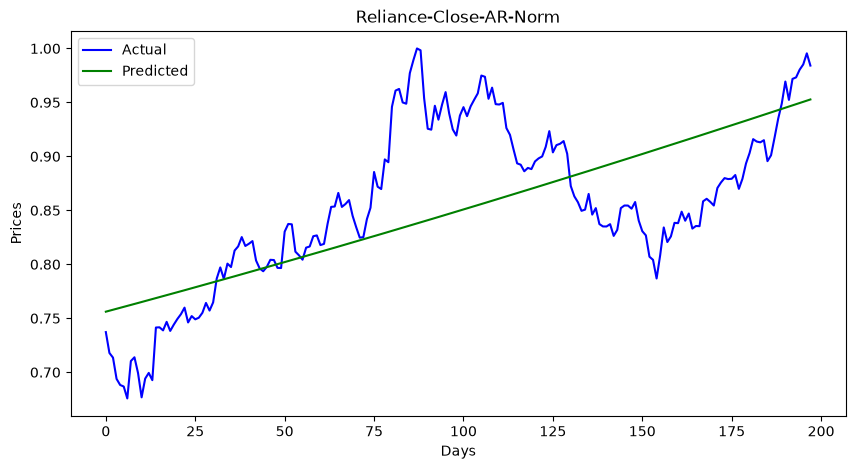

In [17]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","Reliance-Close-AR-Norm","Days","Prices")

In [18]:
len(data1)

992

In [19]:
y_test

array([[0.73720686],
       [0.71786992],
       [0.713542  ],
       [0.69385089],
       [0.68820668],
       [0.68678936],
       [0.67572893],
       [0.71037799],
       [0.71387095],
       [0.69929254],
       [0.67676651],
       [0.69410376],
       [0.69939378],
       [0.69266134],
       [0.7414336 ],
       [0.74163609],
       [0.7388013 ],
       [0.74669807],
       [0.73829503],
       [0.74411635],
       [0.74933023],
       [0.75381018],
       [0.75985916],
       [0.74614106],
       [0.75203841],
       [0.74902644],
       [0.75051984],
       [0.75507568],
       [0.76421237],
       [0.75715098],
       [0.76471865],
       [0.78671291],
       [0.79711536],
       [0.78651056],
       [0.80063348],
       [0.79746975],
       [0.8127317 ],
       [0.81660406],
       [0.82523488],
       [0.81698374],
       [0.81903388],
       [0.82151428],
       [0.80356958],
       [0.79622941],
       [0.79357222],
       [0.79757106],
       [0.80417689],
       [0.803

In [20]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [21]:
aTestNormTable

,Close
0,0.737207
1,0.71787
2,0.713542
3,0.693851
4,0.688207
...,...
193,0.973173
194,0.980328
195,0.985171
196,0.995463


In [22]:
actual_stock_price_test_ori=ms.inverse_transform(aTestNormTable)
actual_stock_price_test_ori

array([[1055.42492676],
       [1038.06689453],
       [1034.18188477],
       [1016.50592041],
       [1011.43933105],
       [1010.16705322],
       [1000.23852539],
       [1031.3416748 ],
       [1034.47717285],
       [1021.39068604],
       [1001.16992187],
       [1016.73291016],
       [1021.48156738],
       [1015.43811035],
       [1059.21911621],
       [1059.40087891],
       [1056.85620117],
       [1063.94482422],
       [1056.4017334 ],
       [1061.62731934],
       [1066.30761719],
       [1070.32910156],
       [1075.7590332 ],
       [1063.44482422],
       [1068.73864746],
       [1066.03491211],
       [1067.37548828],
       [1071.46508789],
       [1079.66674805],
       [1073.32800293],
       [1080.12121582],
       [1099.86462402],
       [1109.20251465],
       [1099.6829834 ],
       [1112.3605957 ],
       [1109.52062988],
       [1123.22070312],
       [1126.69677734],
       [1134.44433594],
       [1127.03759766],
       [1128.87792969],
       [1131.104

In [23]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])
actual_stock_price_test_oriA

,Close
0,1055.424927
1,1038.066895
2,1034.181885
3,1016.50592
4,1011.439331
...,...
193,1267.243042
194,1273.665527
195,1278.013184
196,1287.251709


In [24]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [25]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

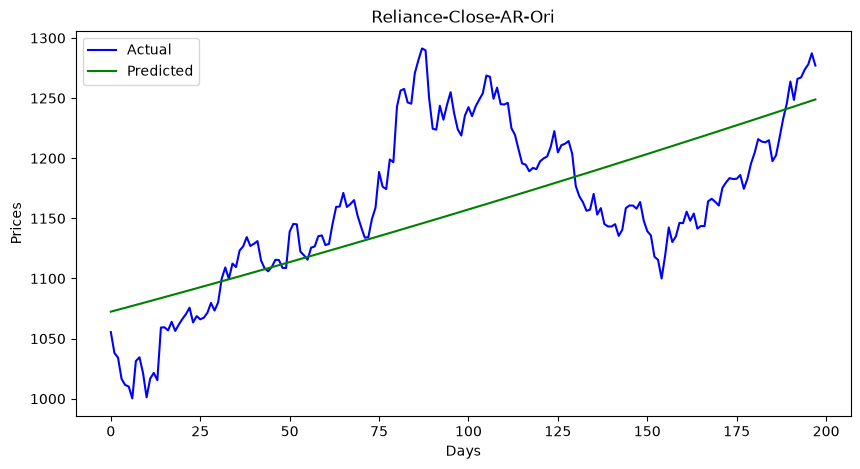

In [26]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","Reliance-Close-AR-Ori","Days","Prices")

In [27]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 54.37085023690524
MAPE-Testset: 0.03777907035274242


In [28]:
# making forecast by adding 3 days

forecast=model_fit.predict(len(data1), len(data1)+3)

In [29]:
forecast

array([0.95382786, 0.95492661, 0.95602628, 0.95712687])

In [30]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [31]:
forecast_stock_price_test_oriF

,Closefore
0,1249.877365
1,1250.863671
2,1251.850802
3,1252.838758


In [32]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

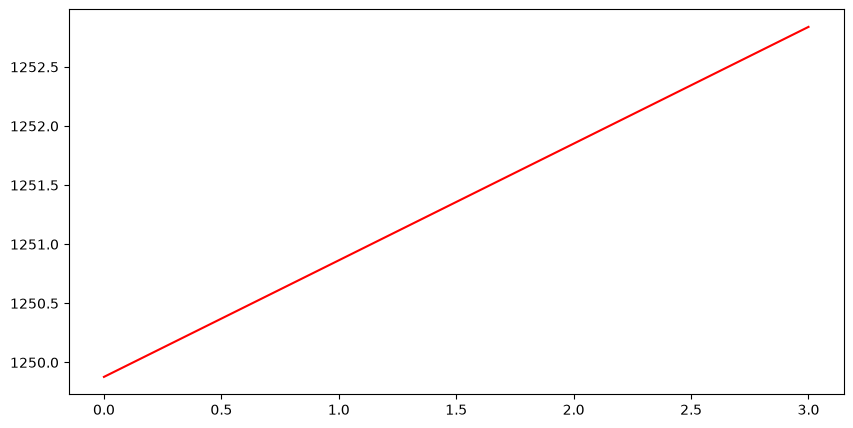

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[794:992], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")